In [28]:
import pandas as pd

import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,HistGradientBoostingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df=pd.read_csv('heart_disease_data.csv')

In [3]:
data=df.copy()

In [4]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
data.shape

(303, 14)

In [7]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [10]:
X=data.drop(columns='target')
y=data['target']

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "Gaussian": GaussianNB()
}

In [15]:

result=[]
for name,model in models.items():
    scores=cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='balanced_accuracy'
    ).mean()
    result.append([name,scores])

In [16]:
cv=pd.DataFrame(result,columns=['Name','Bal_accuracy'])
cv.sort_values(by='Bal_accuracy',ascending=False)

,Name,Bal_accuracy
2,Extra Trees,0.840158
4,CatBoost,0.832466
0,Logistic Regression,0.829384
1,Random Forest,0.825680
3,HistGradientBoosting,0.821277
6,Gaussian,0.802461
5,XGBoost,0.786105


In [19]:
#Hyper tuning Extra Trees

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

extra = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='balanced_accuracy',
    random_state=42,
    n_jobs=-1
)

extra.fit(X_train, y_train)


,estimator,ExtraTreesCla...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,30
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [20]:
#Hyper tuning CatBoost

param_grid = {
    'iterations': [100, 200, 300, 500],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7]
}

cat = RandomizedSearchCV(
    CatBoostClassifier(verbose=0, random_state=42),
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='balanced_accuracy',
    random_state=42,
    n_jobs=-1
)

cat.fit(X_train, y_train)

,estimator,<catboost.cor...t 0x11dd9cd70>
,param_distributions,"{'depth': [4, 6, ...], 'iterations': [100, 200, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.01, 0.05, ...]}"
,n_iter,30
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [21]:
#Hyper tuning Logistic 

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg', 'saga'],
    'max_iter': [2000, 5000, 10000]
}

logist = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='balanced_accuracy',
    random_state=42,
    n_jobs=-1
)

logist.fit(X_train, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_distributions,"{'C': [0.01, 0.1, ...], 'max_iter': [2000, 5000, ...], 'solver': ['lbfgs', 'newton-cg', ...]}"
,n_iter,15
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [23]:
results = pd.DataFrame({
    'Model': ['CatBoostClassifier','ExtraTreesClassifier','LogisticRegression'],
    'Best_CV_Score': [
        cat.best_score_,
        extra.best_score_,
        logist.best_score_
    ]
})

results.sort_values('Best_CV_Score', ascending=False)

,Model,Best_CV_Score
0,CatBoostClassifier,0.847708
1,ExtraTreesClassifier,0.843862
2,LogisticRegression,0.829384


In [24]:
best_model=cat.best_estimator_

In [26]:
pred=best_model.predict(X_test)

In [29]:
print("Accuracy:", accuracy_score(y_test, pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred))

Accuracy: 0.819672131147541
Balanced Accuracy: 0.8062770562770563

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61


Confusion Matrix
[[18 10]
 [ 1 32]]


     Feature  Importance
2         cp   18.645946
12      thal   16.671075
11        ca   15.130829
9    oldpeak    7.762739
10     slope    6.814552
4       chol    5.318542
7    thalach    5.279887
8      exang    5.240636
1        sex    4.998710
6    restecg    4.913468
0        age    4.833141
3   trestbps    3.745804
5        fbs    0.644672


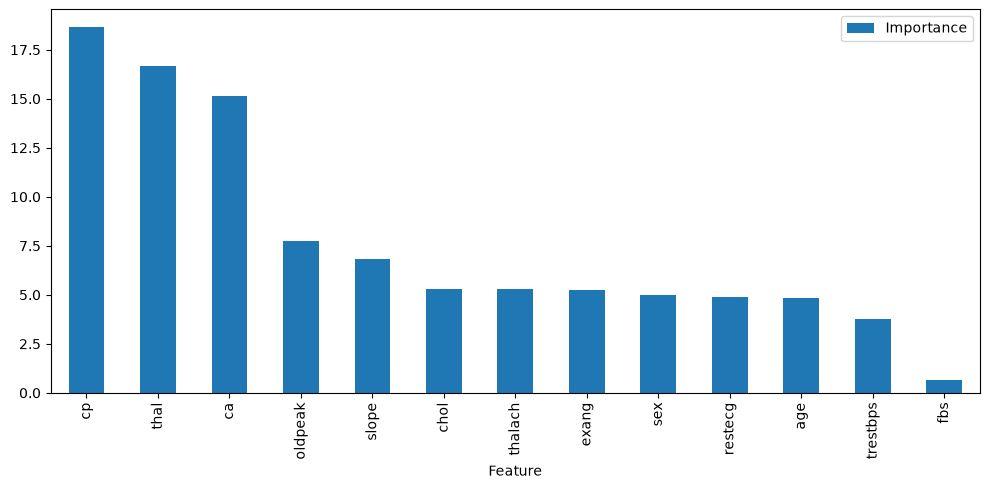

In [30]:
importance = best_model.feature_importances_

fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(fi)

fi.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.tight_layout()
plt.show()

In [31]:
joblib.dump(best_model,'best_model.joblib')

['best_model.joblib']